## Свободный спуск вагонетки по канатной дороге

Уравнение движения


$$m \ddot{s}(t) + \mu \dot{s}(t) + k s(t) = m g \sin(\alpha) + \mu U$$


Итоговая постановка задачи Коши


\begin{cases}
80 \ddot{s}(t) + 75 \dot{s}(t) + 650 s(t) = 353.3, \\
s(0) = 0, \\
\dot{s}(0) = 1.5
\end{cases}



In [31]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from deepxde.backend import tf
import torch
import torch.nn as nn
from torch.autograd import grad

In [32]:
def pde(t, u):
    u1 = u[:, 0:1]   # s
    u2 = u[:, 1:2]   # s'

    du1_dt = dde.grad.jacobian(u, t, i=0)
    du2_dt = dde.grad.jacobian(u, t, i=1)

    eq1 = du1_dt - u2
    eq2 = du2_dt + 0.9375 * u2 + 8.125 * u1 - 4.41625

    return [eq1, eq2]

def exact_solution(t):
    s = (
        np.exp(-0.46875 * t)
        * (-0.5437 * np.cos(2.813 * t) + 0.442 * np.sin(2.813 * t))
        + 0.5437
    )

    ds = (
        np.exp(-0.46875 * t)
        * (
            - 0.46875 * (0.5437 * np.cos(2.813 * t) - 0.442 * np.sin(2.813 * t))
            + 2.813 * (0.5437 * np.sin(2.813 * t) + 0.442 * np.cos(2.813 * t))
        )
    )

    return np.hstack([s, ds])


In [33]:
geom = dde.geometry.TimeDomain(0, 10)

def boundary(t, on_initial):
    return on_initial
bc1 = dde.icbc.IC(geom, lambda t: np.zeros_like(t), boundary, component=0)
bc2 = dde.icbc.IC(geom, lambda t: 1.5 * np.ones_like(t), boundary, component=1)

data = dde.data.PDE(
    geom,
    pde,
    [bc1, bc2],
    num_domain=200,
    num_boundary=20,
    solution=exact_solution,
    num_test=500
)
layer_size = [1] + [100] * 4 + [2]
net = dde.nn.FNN(layer_size, "tanh", "Glorot normal")
model = dde.Model(data, net)

model.compile(
    "adam",
    lr=1e-3,
    loss_weights=[1, 1, 10, 10],
    metrics=["l2 relative error"]
)

Compiling model...
'compile' took 0.000539 s



In [34]:
losshistory, train_state = model.train(iterations=10000)
model.compile("adam", lr=1e-4)
losshistory, train_state = model.train(iterations=10000)

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [9.95e-02, 2.08e+01, 0.00e+00, 2.25e+01]    [1.05e-01, 2.10e+01, 0.00e+00, 2.25e+01]    [1.14e+00]    
1000      [3.50e-02, 1.17e-02, 3.81e-04, 1.46e-05]    [3.53e-02, 1.26e-02, 3.81e-04, 1.46e-05]    [4.55e-01]    
2000      [2.64e-02, 1.38e-02, 2.62e-04, 6.40e-06]    [2.79e-02, 1.46e-02, 2.62e-04, 6.40e-06]    [4.13e-01]    
3000      [1.96e-02, 4.28e-03, 1.39e-04, 1.04e-06]    [2.06e-02, 4.50e-03, 1.39e-04, 1.04e-06]    [3.78e-01]    
4000      [9.96e-03, 2.58e-03, 4.97e-06, 1.21e-05]    [1.05e-02, 2.72e-03, 4.97e-06, 1.21e-05]    [3.23e-01]    
5000      [5.46e-03, 9.74e-04, 1.16e-05, 2.07e-05]    [5.98e-03, 1.07e-03, 1.16e-05, 2.07e-05]    [2.86e-01]    
6000      [3.76e-03, 7.91e-04, 1.11e-05, 3.00e-06]    [4.14e-03, 8.31e-04, 1.11e-05, 3.00e-06]    [2.67e-01]    
7000      [2.66e-03, 3.81e-04, 1.02e-06, 2.12e-07]    [2.92e-03, 4.13e-04, 1.

In [35]:
t_test = np.linspace(0, 10, 800).reshape(-1, 1)
u_pred_dde = model.predict(t_test)
u_exact = exact_solution(t_test)

In [36]:
class TorchPINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i + 1]))

    def forward(self, t):
        x = t
        for layer in self.layers[:-1]:
            x = torch.tanh(layer(x))
        return self.layers[-1](x)


In [37]:
def pde_residual(t, u):
    u1 = u[:, 0:1]   # s
    u2 = u[:, 1:2]   # s'

    du1_dt = grad(u1, t, torch.ones_like(u1), create_graph=True)[0]
    du2_dt = grad(u2, t, torch.ones_like(u2), create_graph=True)[0]

    eq1 = du1_dt - u2
    eq2 = du2_dt + 0.9375 * u2 + 8.125 * u1 - 4.41625

    return eq1, eq2

def exact_solution_torch(t):
    t_np = t.detach().cpu().numpy().flatten()
    s = (
        np.exp(-0.46875 * t_np)
        * (-0.5437 * np.cos(2.813 * t_np) + 0.442 * np.sin(2.813 * t_np))
        + 0.5437
    )
    ds = np.gradient(s, t_np)
    return s, ds

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_torch = TorchPINN([1, 128, 128, 128, 2]).to(device)
optimizer = torch.optim.Adam(model_torch.parameters(), lr=1e-3)

t_domain = torch.linspace(0, 10, 400).view(-1, 1).to(device)
t_domain.requires_grad_(True)

t0 = torch.tensor([[0.0]], device=device, requires_grad=True)

epochs = 20000
for epoch in range(epochs):
    optimizer.zero_grad()

    u = model_torch(t_domain)
    eq1, eq2 = pde_residual(t_domain, u)

    pde_loss = torch.mean(eq1**2) + torch.mean(eq2**2)

    u0 = model_torch(t0)
    ic_loss = (u0[0, 0] - 0.0)**2 + (u0[0, 1] - 1.5)**2

    loss = pde_loss + 100.0 * ic_loss
    loss.backward()
    optimizer.step()

    if epoch % 2000 == 0:
        print(f"Epoch {epoch}: loss={loss.item():.3e}")


Using device: cpu
Epoch 0: loss=2.798e+02
Epoch 2000: loss=3.864e-02
Epoch 4000: loss=2.186e-02
Epoch 6000: loss=1.673e-02
Epoch 8000: loss=1.284e-02
Epoch 10000: loss=9.321e-03
Epoch 12000: loss=1.527e-02
Epoch 14000: loss=5.995e-03
Epoch 16000: loss=3.016e-03
Epoch 18000: loss=2.393e-03


In [39]:
t_test = torch.linspace(0, 10, 800).view(-1, 1).to(device)
with torch.no_grad():
    u_pred = model_torch(t_test).cpu().numpy()

t_np = t_test.cpu().numpy().flatten()
s_exact, ds_exact = exact_solution_torch(t_test.cpu())

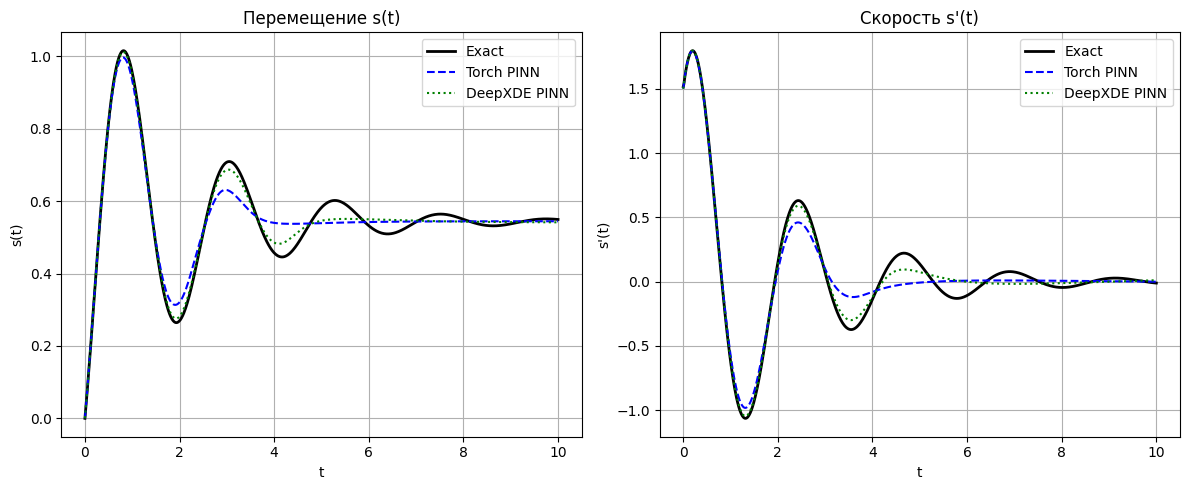

In [42]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_np, s_exact, 'k', linewidth=2, label='Exact')
plt.plot(t_np, u_pred[:, 0], 'b--', label='Torch PINN')
plt.plot(t_np, u_pred_dde[:, 0], 'g:', label='DeepXDE PINN')
plt.xlabel('t')
plt.ylabel('s(t)')
plt.legend()
plt.grid(True)
plt.title('Перемещение s(t)')

plt.subplot(1, 2, 2)

plt.plot(t_np, ds_exact, 'k', linewidth=2, label='Exact')
plt.plot(t_np, u_pred[:, 1], 'b--', label='Torch PINN')
plt.plot(t_np, u_pred_dde[:, 1], 'g:', label='DeepXDE PINN')

plt.xlabel('t')
plt.ylabel("s'(t)")
plt.legend()
plt.grid(True)
plt.title("Скорость s'(t)")

plt.tight_layout()
plt.show()
